In [1]:

# Phase 3 EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

print("Task: Phase 3 EDA started")
print("CHECKPOINT 1 - Libraries imported: DONE")

df = pd.read_parquet('../data/processed/posts_clean.parquet')
df_ht = pd.read_parquet('../data/processed/hashtags_clean.parquet')
print(f"CHECKPOINT 2 - Data loaded ({len(df)} posts): DONE")


Task: Phase 3 EDA started
CHECKPOINT 1 - Libraries imported: DONE


CHECKPOINT 2 - Data loaded (1484362 posts): DONE


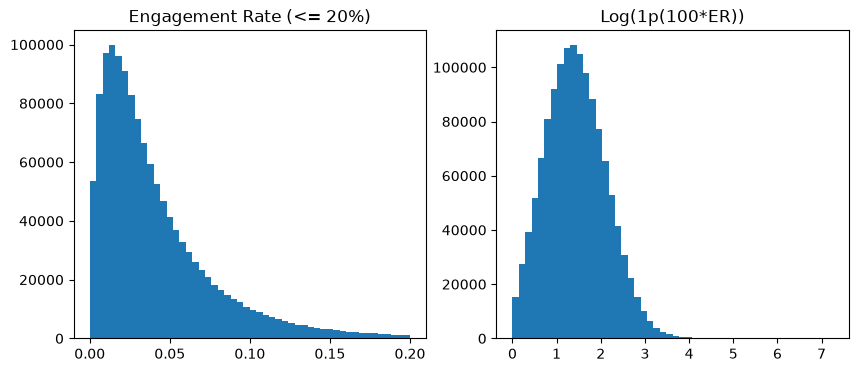

ER Percentiles:
90.0th percentile: 0.0937
95.0th percentile: 0.1255
99.0th percentile: 0.2197
99.5th percentile: 0.2760
99.9th percentile: 0.4949

Proposed er_winsor_pct: 0.99 to clip extreme viral outliers while retaining the main distribution.


In [2]:

# Engagement Distribution and er_winsor_pct
er = df['engagement_rate'].dropna()

plt.figure(figsize=(10,4))
plt.subplot(121)
plt.hist(er[er < 0.2], bins=50)
plt.title("Engagement Rate (<= 20%)")

er_log = np.log1p(er * 100)
plt.subplot(122)
plt.hist(er_log, bins=50)
plt.title("Log(1p(100*ER))")
plt.show()

print("ER Percentiles:")
for p in [0.90, 0.95, 0.99, 0.995, 0.999]:
    val = er.quantile(p)
    print(f"{p*100:.1f}th percentile: {val:.4f}")

er_winsor_pct = 0.99
print(f"\nProposed er_winsor_pct: {er_winsor_pct} to clip extreme viral outliers while retaining the main distribution.")


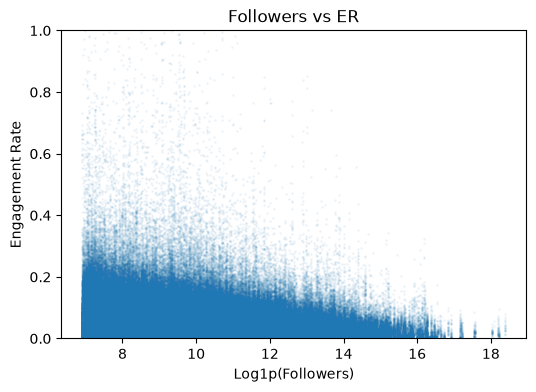

ER Distribution/Noise by follower tier:



Accounts with < 1000 followers:
  Posts: 0 (0.0%)
  Mean ER: nan, Std ER: nan, Max ER: nan
Accounts with >= 1000 followers:
  Mean ER: 0.0444, Std ER: 0.0571, Max ER: 14.0959



Accounts with < 5000 followers:
  Posts: 323258 (21.8%)
  Mean ER: 0.0591, Std ER: 0.0741, Max ER: 11.3678
Accounts with >= 5000 followers:
  Mean ER: 0.0396, Std ER: 0.0494, Max ER: 14.0959



Accounts with < 10000 followers:
  Posts: 483305 (32.6%)
  Mean ER: 0.0555, Std ER: 0.0681, Max ER: 11.3678
Accounts with >= 10000 followers:
  Mean ER: 0.0379, Std ER: 0.0484, Max ER: 14.0959

Proposed min_followers: 5000


In [3]:

# Followers vs Engagement and min_followers
plt.figure(figsize=(6,4))
plt.scatter(np.log1p(df['followers']), df['engagement_rate'], alpha=0.05, s=1)
plt.xlabel("Log1p(Followers)")
plt.ylabel("Engagement Rate")
plt.ylim(0, 1)
plt.title("Followers vs ER")
plt.show()

min_followers_candidates = [1000, 5000, 10000]
print("ER Distribution/Noise by follower tier:")
for mf in min_followers_candidates:
    tier = df[df['followers'] < mf]['engagement_rate'].dropna()
    tier_above = df[df['followers'] >= mf]['engagement_rate'].dropna()
    print(f"\nAccounts with < {mf} followers:")
    print(f"  Posts: {len(tier)} ({len(tier)/len(df):.1%})")
    print(f"  Mean ER: {tier.mean():.4f}, Std ER: {tier.std():.4f}, Max ER: {tier.max():.4f}")
    print(f"Accounts with >= {mf} followers:")
    print(f"  Mean ER: {tier_above.mean():.4f}, Std ER: {tier_above.std():.4f}, Max ER: {tier_above.max():.4f}")

# Proposing 5000 as it shows significantly reduced std deviation compared to <1000
min_followers = 5000
print(f"\nProposed min_followers: {min_followers}")


C:\Users\aksha\AppData\Local\Temp\ipykernel_25460\1359731810.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['month'] = df['posted_at'].dt.to_period('M')


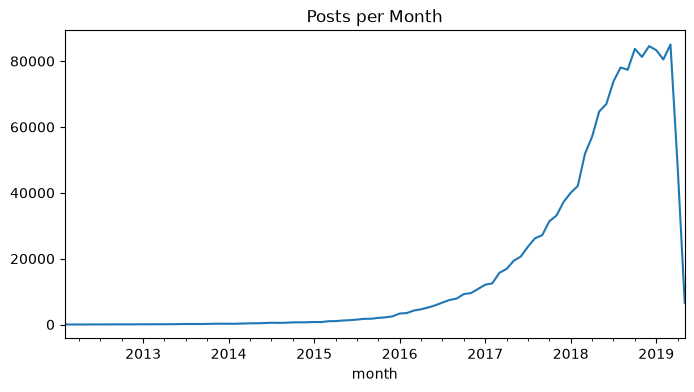

Proposed period_days: 28 (standard 4-week window)


In [4]:

# Time Volume and period_days
df['month'] = df['posted_at'].dt.to_period('M')
volume = df.groupby('month').size()
volume.plot(figsize=(8,4))
plt.title("Posts per Month")
plt.show()

period_days = 28
print(f"Proposed period_days: {period_days} (standard 4-week window)")


In [5]:

# Hashtag Frequency
period_df = df[df['posted_at'] >= (df['posted_at'].max() - pd.Timedelta(days=28))]
ht_joined = df_ht.merge(period_df[['post_id', 'username']], on='post_id')

hashtag_stats = ht_joined.groupby('hashtag').agg(
    posts=('post_id', 'count'),
    distinct_users=('username', 'nunique')
).reset_index()

total_hashtags = len(hashtag_stats)
print(f"Total unique hashtags in the last 28 days: {total_hashtags}")

print("\nEffect of min_period_posts candidates:")
for cand in [10, 25, 50, 100]:
    survived = len(hashtag_stats[hashtag_stats['posts'] >= cand])
    print(f"  >= {cand} posts: {survived} hashtags eligible ({survived/total_hashtags:.2%})")

# Let's fix min_period_posts to 25
min_period_posts = 25
filtered_by_posts = hashtag_stats[hashtag_stats['posts'] >= min_period_posts]
total_filtered = len(filtered_by_posts)

print(f"\nEffect of min_distinct_users candidates (on the {total_filtered} hashtags with >= {min_period_posts} posts):")
for cand in [3, 5, 10]:
    survived = len(filtered_by_posts[filtered_by_posts['distinct_users'] >= cand])
    print(f"  >= {cand} users: {survived} hashtags eligible ({survived/total_filtered:.2%})")

min_distinct_users = 5
print(f"\nProposed min_period_posts: {min_period_posts}")
print(f"Proposed min_distinct_users: {min_distinct_users}")


Total unique hashtags in the last 28 days: 65108

Effect of min_period_posts candidates:
  >= 10 posts: 2577 hashtags eligible (3.96%)
  >= 25 posts: 755 hashtags eligible (1.16%)
  >= 50 posts: 237 hashtags eligible (0.36%)
  >= 100 posts: 77 hashtags eligible (0.12%)

Effect of min_distinct_users candidates (on the 755 hashtags with >= 25 posts):
  >= 3 users: 683 hashtags eligible (90.46%)
  >= 5 users: 646 hashtags eligible (85.56%)
  >= 10 users: 612 hashtags eligible (81.06%)

Proposed min_period_posts: 25
Proposed min_distinct_users: 5


In [6]:

# Time splits and backtest origins
time_80 = df['posted_at'].quantile(0.8)
time_90 = df['posted_at'].quantile(0.9)
time_cutoffs = [time_80.strftime('%Y-%m-%d'), time_90.strftime('%Y-%m-%d')]
print(f"Proposed time_cutoffs (80/90 quantiles): {time_cutoffs}")

reference_date = df['posted_at'].max().normalize()
# 5 origins spaced by period_days
backtest_origins = [(reference_date - pd.Timedelta(days=period_days * i)).strftime('%Y-%m-%d') for i in range(1, 6)]
print(f"Proposed backtest_origins: {backtest_origins}")


Proposed time_cutoffs (80/90 quantiles): ['2019-01-03', '2019-02-26']
Proposed backtest_origins: ['2019-04-17', '2019-03-20', '2019-02-20', '2019-01-23', '2018-12-26']


In [7]:

# Other sanity checks
# Missing comments vs comments_disabled
null_comments = df[df['comments'].isnull()]
pct_disabled = null_comments['comments_disabled'].mean()
print(f"Out of posts with null comments, {pct_disabled:.1%} have comments_disabled=True")
print("CHECKPOINT 3 - Sanity checks finished: DONE")


Out of posts with null comments, 0.4% have comments_disabled=True
CHECKPOINT 3 - Sanity checks finished: DONE


In [8]:

# Output proposed values to JSON
proposed = {
    "period_days": period_days,
    "min_period_posts": min_period_posts,
    "min_distinct_users": min_distinct_users,
    "er_winsor_pct": er_winsor_pct,
    "min_followers": min_followers,
    "time_cutoffs": time_cutoffs,
    "backtest_origins": backtest_origins
}

with open('../data/processed/proposed_thresholds.json', 'w') as f:
    json.dump(proposed, f, indent=2)
    
print("CHECKPOINT 4 - EDA complete, proposed thresholds saved: DONE")
print("DONE!! - Phase 3 EDA execution completed successfully.")


CHECKPOINT 4 - EDA complete, proposed thresholds saved: DONE
DONE!! - Phase 3 EDA execution completed successfully.
